# SDSSRM-XCS morphology: Centroid shift, concentration, position angle

This section of the project measures some hot intra-cluster medium (ICM) morphology metrics for the SDSSRM-XCS sample of 150 galaxy clusters, with the goal of exploring if scaling relation scatter is at all dependent on the arrangement of the ICM. 

We measure the centroid coordinate and position angle of our clusters. The centroid is the first moment of the 2D surface brightness distribution (the average position, weighted by the surface brightness) and acts as an alternate (to the peak) definition of the central coordinate - it is also useful when combined with the peak, allowing for the creation of a metric for cluster disturbedness. The second moment of the 2D surface brightness distribution is essentially the covariance matrix, which can then be diagonalised to find the rotation angle (which can be turned into a position angle) and the axis length ratio of the (assumed) ellipse that describes the ICM emission.

We also measure the centroid shift ($w$), which is a standard measure of relaxation for galaxy clusters, and the concentration index ($c$) which is a measure of the fraction of ICM emission coming from the core of the cluster, and is a diagnostic for cool-core systems (in and of itself another relaxation measure, as cool-core clusters are generally relaxed because they have not experienced recent merger activity).

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from astropy.units import Quantity, UnitConversionError
from astropy.cosmology import LambdaCDM
from shutil import rmtree
import os
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse, FancyArrow
from matplotlib.ticker import FuncFormatter

import xga
xga.NUM_CORES = 40
from xga.samples import ClusterSample
from xga.sourcetools import ang_to_rad

from warnings import warn

# We will ignore some divide by invalid value warnings here - I promise its fine
np.seterr(divide='ignore', invalid='ignore')

%matplotlib inline

## Setting up necessary directories

Here we ensure that the directories we need to store the outputs in have been created:

In [2]:
fix_ap_dist_path = "../../outputs/figures/icm_morphology/centroid_dists/"
os.makedirs(fix_ap_dist_path, exist_ok=True)

centroid_posang_vis_path = "../../outputs/figures/icm_morphology/centroid_posangle_vis/"
os.makedirs(centroid_posang_vis_path, exist_ok=True)

coords_morph_out_path = "../../outputs/result_files/positions_and_morphology/"
os.makedirs(coords_morph_out_path, exist_ok=True)

## Defining any useful functions

Specifically, this is where we define the function that measures the centroid coordinate and the position angle of the ICM distribution - this will be included into XGA at some point, but for now we use this function:

In [3]:
def centroid_shape_estimate(rel_src, ap_rads, cent_coord=None, num_samp=100, 
                            back_inn_rad=None, back_out_rad=None):
    
    if ap_rads is None or ap_rads.isscalar:
        ap_rads = [ap_rads]
    
    if any([back_inn_rad is None, back_out_rad is None, ap_rads[0] is None]):
        back_sub = False
    else:
        back_sub = True
        back_mask = src.get_custom_mask(back_out_rad, back_inn_rad, remove_interlopers=True, 
                                        central_coord=cent_coord)    
    
    cur_rt = src.get_combined_ratemaps()
    data_cp = cur_rt.data.copy()
    
    cont_mask = src.get_interloper_mask()
    
    if back_sub:
        # Find the total mask areas. As the mask is just an array of ones and zeros we can just sum the
        #  whole thing to find the total pixel area covered.
#         src_area = (tot_mask * cur_rt.sensor_mask).sum()
        back_area = (back_mask * cur_rt.sensor_mask).sum()
        
        # Calculate an area normalisation so the background counts can be scaled to the source counts properly
#         area_norm = src_area / back_area
        
#         cur_rt.view(mask=back_mask, zoom_in=True)
        back_rt = np.sum(data_cp*back_mask)/back_area

        data_cp = data_cp - back_rt
        data_cp[data_cp < 0] = 0
    
    if num_samp != 0:
        rng = np.random.default_rng()
#         *tot_mask[..., None]
        all_resamp_msk_data = np.repeat((data_cp*cont_mask)[:, :, np.newaxis], num_samp, axis=2)
        # Resampling the count maps
        all_resamp_msk_data = rng.poisson(all_resamp_msk_data*cur_rt.expmap.data[..., None]) / cur_rt.expmap.data[..., None]
        all_resamp_msk_data[np.isnan(all_resamp_msk_data)] = 0
    
    returns = []
    for ap_rad in ap_rads:
        
        if ap_rad is not None:
            ap_mask = src.get_custom_mask(ap_rad, remove_interlopers=False, central_coord=cent_coord)
        else:
            ap_mask = np.ones(cur_rt.shape)
        
        tot_mask = ap_mask*cont_mask
        
        msk_data = data_cp*tot_mask

        norm_data = msk_data / msk_data.sum()

        arr_x, arr_y = np.meshgrid(np.arange(0, norm_data.shape[1], ), np.arange(0, norm_data.shape[0]))

        x_cen_pix = (norm_data*arr_x).sum()
        y_cen_pix = (norm_data*arr_y).sum()
        cen_pix = [x_cen_pix, y_cen_pix]
        cen_pix_quan = Quantity(cen_pix, 'pix')

        covar = np.zeros((2, 2))
        covar[0, 0] = (norm_data*np.square(arr_x - cen_pix[0])).sum()
        covar[1, 1] = (norm_data*np.square(arr_y - cen_pix[1])).sum()
        covar[0, 1] = (norm_data * (arr_x - cen_pix[0]) * (arr_y - cen_pix[1])).sum()
        covar[1, 0] = covar[0, 1]

        # TODO Try to normalise this output + ensure that it is North of East (does my head in)
        theta = 0.5*np.arctan((2*covar[1, 0]) / (covar[0, 0]-covar[1, 1]))*(180/np.pi)
        mod_theta = theta % 360
        if ((covar[1, 0] > 0 and (covar[0, 0] - covar[1, 1]) < 0) or 
                (covar[1, 0] < 0 and (covar[0, 0] - covar[1, 1]) < 0)):
            mod_theta = mod_theta - 90

        # This turns it (hopefully) from an angle defined from the usual axis (which matplotlib takes as an
        #  angle argument for its ellipse patch) to a position angle defined east from north
        # mod_theta = mod_theta - 90

        # This chunk should normalise the degenerate rotation angles to a range of -90 to 90. First of
        #  all ensure that the angles are within 0-360 degrees
        mod_theta = mod_theta%360
        
        # Quickly put the angles in radians
        rad_mod_theta = np.deg2rad(mod_theta)
        
        # Then we can use this trick, of creating a unit vector for the current angles (sin(theta), cos(theta)), and
        #  the arctan2 function which finds the quadrant of the angle by considering the sign, to restrict to 
        #  -180 to 180 degrees.
        rad_mod_theta = np.arctan2(np.sin(rad_mod_theta), np.cos(rad_mod_theta))

        # At this point, any angle outside of our desired -90 to 90 range will be degenerate (at least as we're thinking
        #  about the rotation of the semi-major axis of an ellipse) with an angle within that range, and we can 
        #  simply subtract or add 180 to bring it within the range
        # Above the target range
        if rad_mod_theta > (np.pi/2):
            rad_mod_theta = rad_mod_theta - np.pi
        elif rad_mod_theta < (-np.pi/2):
            rad_mod_theta = rad_mod_theta + np.pi

        # Then we convert back to degrees
        mod_theta = np.rad2deg(rad_mod_theta)

        eig_pl = ((covar[0, 0] + covar[1, 1]) + np.sqrt((covar[0, 0] - covar[0, 0])**2 + 4*covar[0, 1]**2)) / 2
        eig_mi = ((covar[0, 0] + covar[1, 1]) - np.sqrt((covar[0, 0] - covar[0, 0])**2 + 4*covar[0, 1]**2)) / 2

        x_s = np.sqrt(eig_pl)
        y_s = np.sqrt(eig_mi)

        # If the number of re-samples requested is zero, we end the function here and return (did it like this 
        #  because many of the bits of math using the resampled cov matrix are long and indenting them further 
        #  does not sound like fun)
        if num_samp == 0:
            returns.append([cur_rt.coord_conv(cen_pix_quan, 'deg'), mod_theta, x_s, y_s, None, None, None, None, tot_mask])
            continue
        
        resamp_msk_data = all_resamp_msk_data*tot_mask[..., None]
        resamp_norm_data = resamp_msk_data / resamp_msk_data.sum(axis=(0, 1))

        x_cen_pix_resamp_dist = (resamp_norm_data*arr_x[..., None]).sum(axis=(0, 1))
        y_cen_pix_resamp_dist = (resamp_norm_data*arr_y[..., None]).sum(axis=(0, 1))
        cen_pix_resamp_dist = Quantity([x_cen_pix_resamp_dist, y_cen_pix_resamp_dist], 'pix').T
        cen_deg_resamp_dist = cur_rt.coord_conv(cen_pix_resamp_dist, 'deg')


        resamp_covar = np.zeros((2, 2, num_samp))

        resamp_covar[0, 0, :] = (resamp_norm_data*np.square(arr_x[..., None] - 
                                                            cen_pix_resamp_dist[:, 0].value)).sum(axis=(0, 1))
        resamp_covar[1, 1, :] = (resamp_norm_data*np.square(arr_y[..., None] - 
                                                            cen_pix_resamp_dist[:, 1].value)).sum(axis=(0, 1))

        resamp_covar[0, 1, :] = ((resamp_norm_data*(arr_x[..., None] - cen_pix_resamp_dist[:, 0].value)*
                                  (arr_y[..., None] - cen_pix_resamp_dist[:, 1].value)).sum(axis=(0, 1)))
        resamp_covar[1, 0, :] = resamp_covar[0, 1, :]

        theta_dist = (0.5*np.arctan((2*resamp_covar[1, 0, :]) / 
                                    (resamp_covar[0, 0, :]-resamp_covar[1, 1, :]))*(180/np.pi))
        mod_theta_dist = theta_dist % 360

        rot_bool = (((resamp_covar[1, 0, :] > 0) & ((resamp_covar[0, 0, :] - resamp_covar[1, 1, :]) < 0)) | 
                    ((resamp_covar[1, 0, :] < 0) & ((resamp_covar[0, 0, :] - resamp_covar[1, 1, :]) < 0)))
        mod_theta_dist = mod_theta_dist - (np.full(num_samp, 90)*rot_bool)

        # mod_theta_dist = mod_theta_dist - 90
        
        # This chunk should normalise the degenerate rotation angles to a range of -90 to 90. First of
        #  all ensure that the angles are within 0-360 degrees
        mod_theta_dist = mod_theta_dist%360
        
        # Quickly put the angles in radians
        rad_mod_theta_dist = np.deg2rad(mod_theta_dist)
        
        # Then we can use this trick, of creating a unit vector for the current angles (sin(theta), cos(theta)), and
        #  the arctan2 function which finds the quadrant of the angle by considering the sign, to restrict to 
        #  -180 to 180 degrees.
        rad_mod_theta_dist = np.arctan2(np.sin(rad_mod_theta_dist), np.cos(rad_mod_theta_dist))

        # At this point, any angle outside of our desired -90 to 90 range will be degenerate (at least as we're thinking
        #  about the rotation of the semi-major axis of an ellipse) with an angle within that range, and we can 
        #  simply subtract or add 180 to bring it within the range
        # Above the target range
        abv_range = np.argwhere(rad_mod_theta_dist > (np.pi/2)).flatten()
        rad_mod_theta_dist[abv_range] = rad_mod_theta_dist[abv_range]-np.pi
        # Below the target range
        blw_range = np.argwhere(rad_mod_theta_dist < (-np.pi/2)).flatten()
        rad_mod_theta_dist[blw_range] = rad_mod_theta_dist[blw_range]+np.pi
        
        # Then we convert back to degrees
        mod_theta_dist = np.rad2deg(rad_mod_theta_dist)

        # NOW we have to do some annoying post processing on the angle distribution to avoid a split
        #  angle distribution - imagine a scenario where the PA is very close to 90 or -90 degrees, and the 
        #  resampling we do to estimate uncertainty goes over those limits. You end up with a falsely bimodal PA
        #  distribution, which then of course can throw off your median, and your confidence limits. So we need to
        #  detect these split distributions and recombine them
        # This current median may be 'wrong' in terms of the measurement we want for science (in the case of a 
        #  split distribution), but should serve as an okay reference point to recombine the distributions 
        cur_med_pa = np.nanmedian(mod_theta_dist)
        to_flip = np.argwhere(np.abs(mod_theta_dist - cur_med_pa) > np.abs((mod_theta_dist-180)-cur_med_pa)).flatten()
        mod_theta_dist[to_flip] = (mod_theta_dist[to_flip] - 180)
        
        to_flip = np.argwhere(np.abs(mod_theta_dist - cur_med_pa) > np.abs((mod_theta_dist+180)-cur_med_pa)).flatten()
        mod_theta_dist[to_flip] = (mod_theta_dist[to_flip] + 180)
        
        eig_pl_dist = (((resamp_covar[0, 0, :] + resamp_covar[1, 1, :]) + 
                        np.sqrt((resamp_covar[0, 0, :] - resamp_covar[0, 0, :])**2 + 4*resamp_covar[0, 1, :]**2)) / 2)
        eig_mi_dist = (((resamp_covar[0, 0, :] + resamp_covar[1, 1, :]) - 
                        np.sqrt((resamp_covar[0, 0, :] - resamp_covar[0, 0, :])**2 + 4*resamp_covar[0, 1, :]**2)) / 2)

        x_s_dist = np.sqrt(eig_pl_dist)
        y_s_dist = np.sqrt(eig_mi_dist)

        returns.append([cur_rt.coord_conv(cen_pix_quan, 'deg'), mod_theta, x_s, y_s, cen_deg_resamp_dist, mod_theta_dist, \
            x_s_dist, y_s_dist, tot_mask])
    
    # This is ugly and inefficient and I do not care
    if len(returns) == 1:
        returns = returns[0]
    else:
        new_returns = [[], [], [], [], [], [], [], [], []]      
        for ap_ret in returns:
            for ret_ind, ret_en in enumerate(ap_ret):
                new_returns[ret_ind].append(ret_en)
        returns = new_returns
    
    return returns


def haversine(ra1, dec1, ra2, dec2):
    
#     icm_ra = pos_ang_og_samp_comb['cent_ra'].values
#     icm_dec = pos_ang_og_samp_comb['cent_dec'].values

#     bcg1_ra = pos_ang_og_samp_comb['bcg1_ra'].values
#     bcg1_dec = pos_ang_og_samp_comb['bcg1_dec'].values
    
    hav_sep = 2 * np.arcsin(np.sqrt((np.sin(((dec1*(np.pi / 180))-(dec2*(np.pi / 180))) / 2) ** 2)
                                    + np.cos((dec2 * (np.pi / 180))) * np.cos(dec1 * (np.pi / 180))
                                    * np.sin(((ra1*(np.pi / 180)) - (ra2*(np.pi / 180))) / 2) ** 2))
    # Converting back to degrees from radians
    hav_sep /= (np.pi / 180)
    hav_sep = Quantity(hav_sep, 'deg').to('arcmin')
    
    return hav_sep

## Loading data files

We load the 'base' SDSSRM-XCS sample file, containing some basic information about galaxy cluster names, positions, and redshifts, which will allow us to setup an XGA cluster sample and measure morphological parameters. We will also load the previously measured peak coordinates that are required for centroid shift constraints.

### SDSSRM-XCS base sample

In [4]:
sdssxcs_base = pd.read_csv("../../sample_files/SDSSRM-XCS_base_sample.csv")
sdssxcs_base.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous
0,SDSSXCS-124,124,0.80058,-6.09182,0.798261,-6.091694,0.2475,1181.028,21.202,23.203,109.550,4.490,XMMXCS J000312.1-060530.5,1.018410,True,False
1,SDSSXCS-2789,2789,0.95554,2.06802,0.956981,2.066469,0.1053,1007.861,17.194,17.202,38.904,2.830,XMMXCS J000349.3+020404.8,0.827942,True,False
2,SDSSXCS-290,290,2.72264,29.16102,2.714137,29.161154,0.3485,913.052,30.879,31.210,105.096,5.994,XMMXCS J001053.4+290939.6,1.009990,True,False
3,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True
4,SDSSXCS-134,134,4.90839,3.60982,4.911069,3.599257,0.2773,1123.321,19.219,19.226,108.604,4.792,XMMXCS J001938.0+033635.3,1.016645,True,False
5,SDSSXCS-119,119,8.46470,-7.86290,8.471426,-7.869543,0.3042,944.275,46.422,46.747,128.192,5.697,XMMXCS J003351.5-075146.4,1.050926,True,False


### SDSSRM-XCS X-ray peak coordinates

In [5]:
sdssxcs_peak = pd.read_csv("../../outputs/result_files/positions_and_morphology/xga_xmm_peak_coords.csv")
sdssxcs_peak.head(6)

,name,peak_ra,peak_dec
0,SDSSXCS-124,0.800342,-6.093069
1,SDSSXCS-2789,0.958583,2.064764
2,SDSSXCS-290,2.724218,29.160439
3,SDSSXCS-1018,4.408159,-0.881215
4,SDSSXCS-134,4.909123,3.604111
5,SDSSXCS-119,8.468353,-7.856819


### Combining tables

In [6]:
sdssxcs_samp = pd.merge(sdssxcs_base, sdssxcs_peak, left_on='name', right_on='name', how='outer')

## Defining an XGA ClusterSample

This is the one section of this project that produces new measurements of galaxy clusters properties for the SDSSRM-XCS sample - we declare an XGA ClusterSample object for easy handling of the large number of XMM observations utilized in this work, though morphology measurement capabilities are not directly implemented in XGA at the time of writing (they will be in the future however):

In [7]:
srcs = ClusterSample(sdssxcs_samp['xapa_ra'].values, sdssxcs_samp['xapa_dec'].values, 
                     sdssxcs_samp['z'].values, sdssxcs_samp['name'].values, 
                     r500=Quantity(sdssxcs_samp['r500'].values, 'kpc'), use_peak=False, 
                     clean_obs=False)
srcs.info()

Declaring BaseSource Sample:   0%|                                                    | 0/150 [00:00<?, ?it/s]

Declaring BaseSource Sample:   1%|▎                                           | 1/150 [00:03<09:20,  3.76s/it]

Declaring BaseSource Sample:   1%|▌                                           | 2/150 [00:08<10:50,  4.40s/it]

Declaring BaseSource Sample:   2%|▉                                           | 3/150 [00:14<12:40,  5.17s/it]

Declaring BaseSource Sample:   3%|█▏                                          | 4/150 [00:16<09:42,  3.99s/it]

...

Setting up Galaxy Clusters:  99%|██████████████████████████████████████████▋| 149/150 [20:06<00:05,  5.46s/it]

Setting up Galaxy Clusters: 100%|███████████████████████████████████████████| 150/150 [20:10<00:00,  5.13s/it]

Setting up Galaxy Clusters: 100%|███████████████████████████████████████████| 150/150 [20:10<00:00,  8.07s/it]


-----------------------------------------------------
Number of Sources - 150
Redshift Information - True
Sources with ≥1 detection - 150 [100%]
-----------------------------------------------------




/its/home/dt237/.conda/envs/xga_env/lib/python3.12/site-packages/xga/samples/extended.py:308: UserWarning: Non-fatal warnings occurred during the declaration of some sources, to access them please use the suppressed_warnings property of this sample.
  self._check_source_warnings()


## Measuring centroid & PA within a fixed aperture

First of all, we measure the centroid position within a fixed aperture that is centered on the 'start coordinate'. Any identified contaminating sources are removed, to try to avoid biasing the position - background from an annulus outside the aperture is subtracted. As a part of this analysis, we also measure the position angle and the axis ratio of the ellipse. 

Then, visualisations are generated (saved to disk in the 'outputs' section of this repository) and displayed (for a small subset to avoid making this notebook file too large). The centroid position is indicated by the solid cross-hair, and the start position by the dashed cross-hair; the white ellipse indicates the axis sizes (though it has been arbitrarily scaled up in size, the ratio of the axis lengths is the most useful thing), as well as its rotation.

We also attempt to quantify the statistical uncertainty on the quantities we measure here by resampling the count-rate map many times to produce posterior distributions of the properties - these are then used to calculate uncertainties (and the distribution histograms are saved to disk):

SDSSXCS-1018


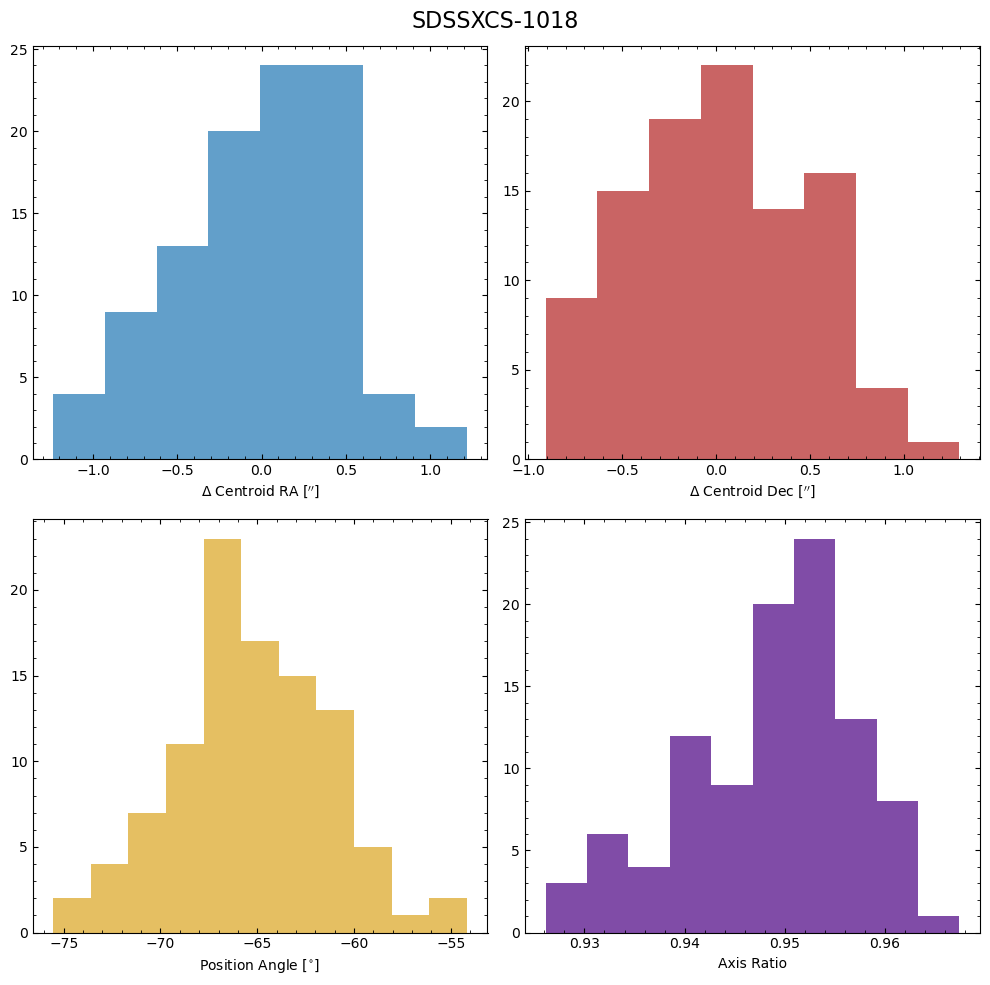

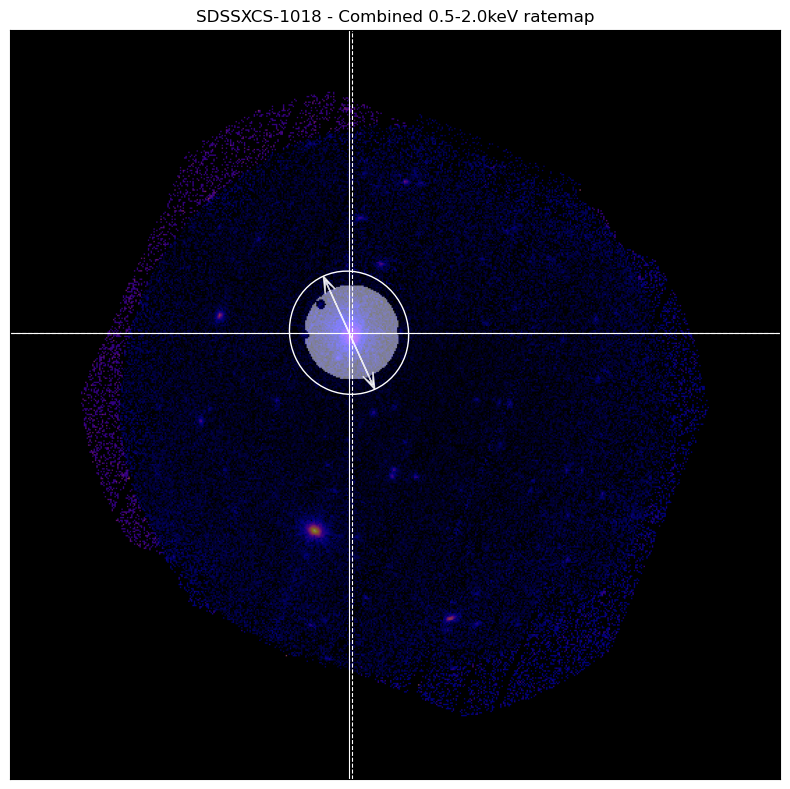

SDSSXCS-10223


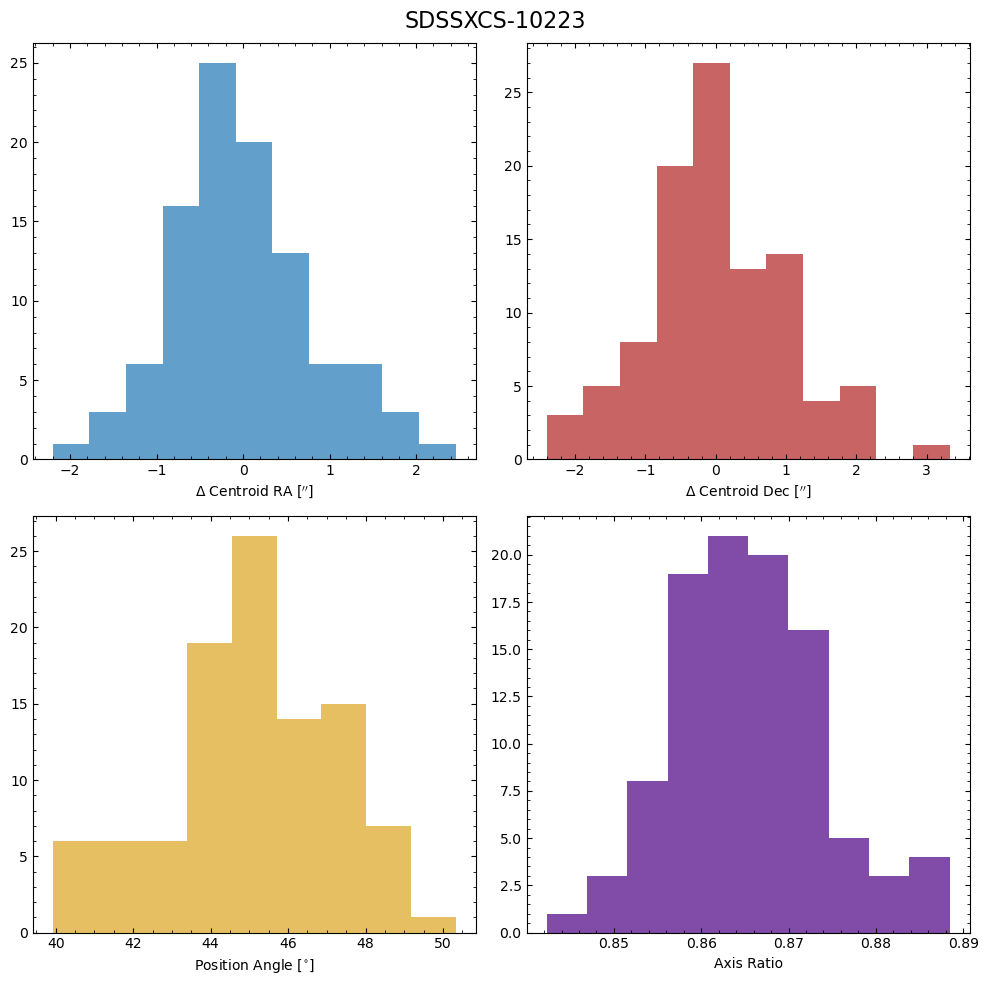

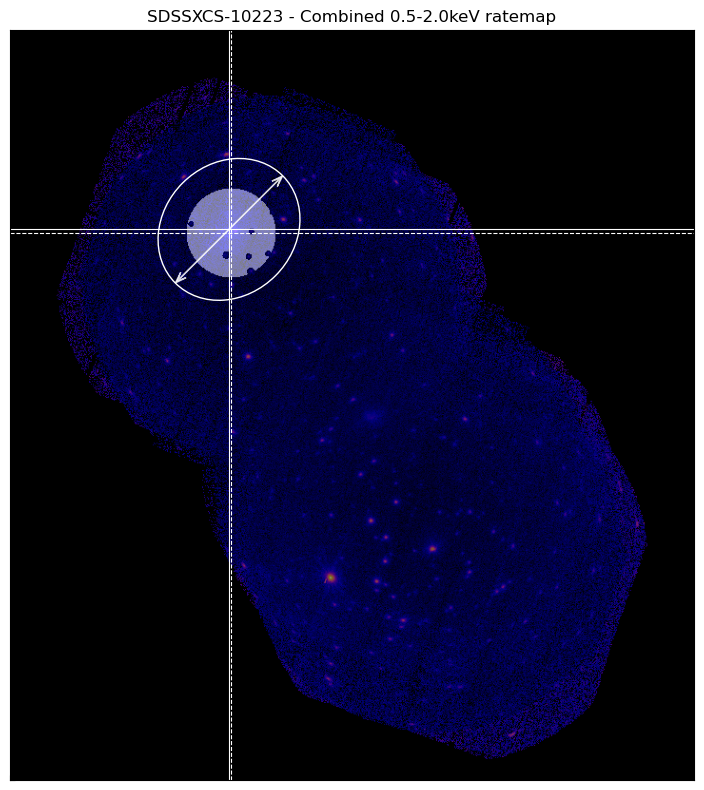

SDSSXCS-103


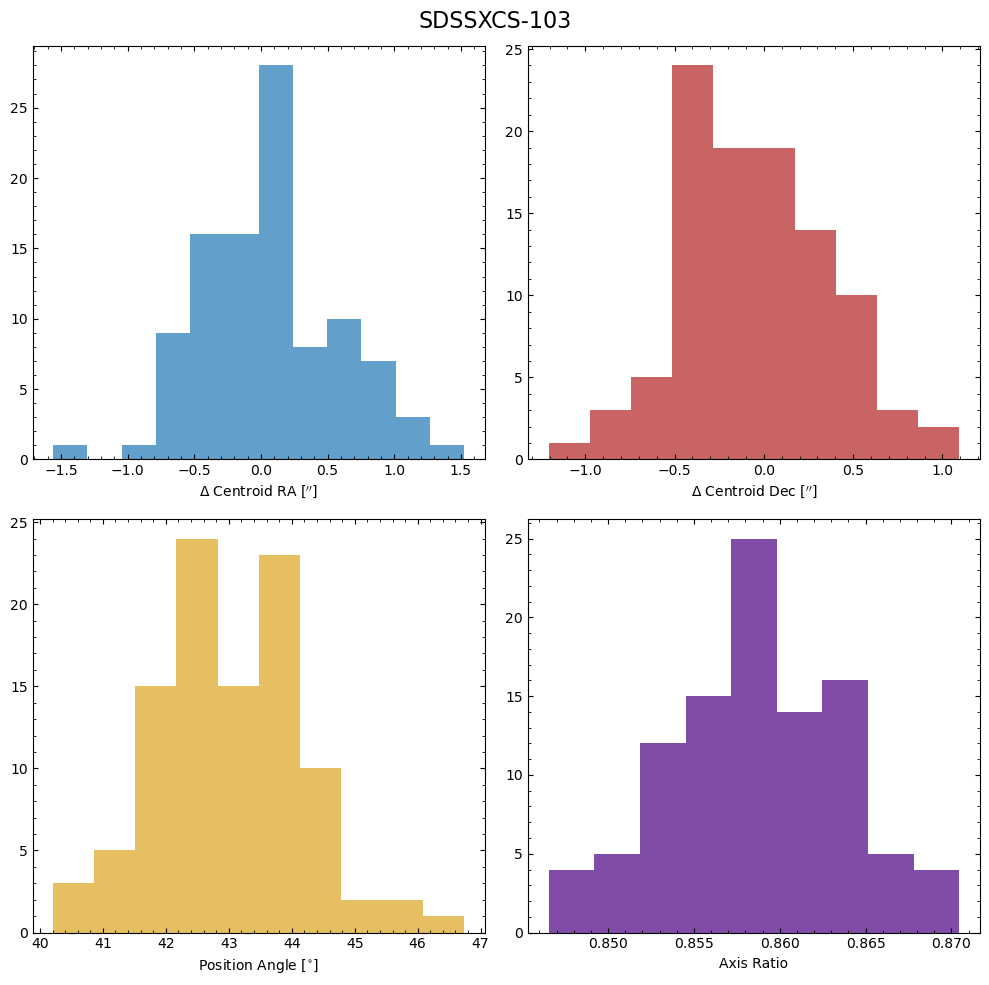

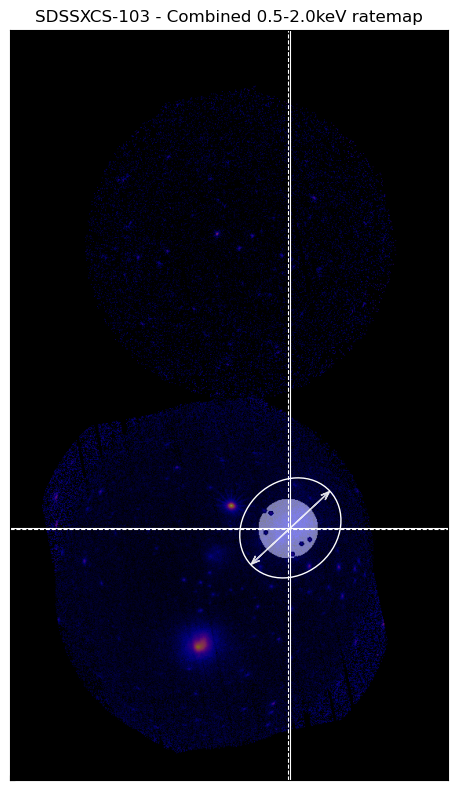

SDSSXCS-10401


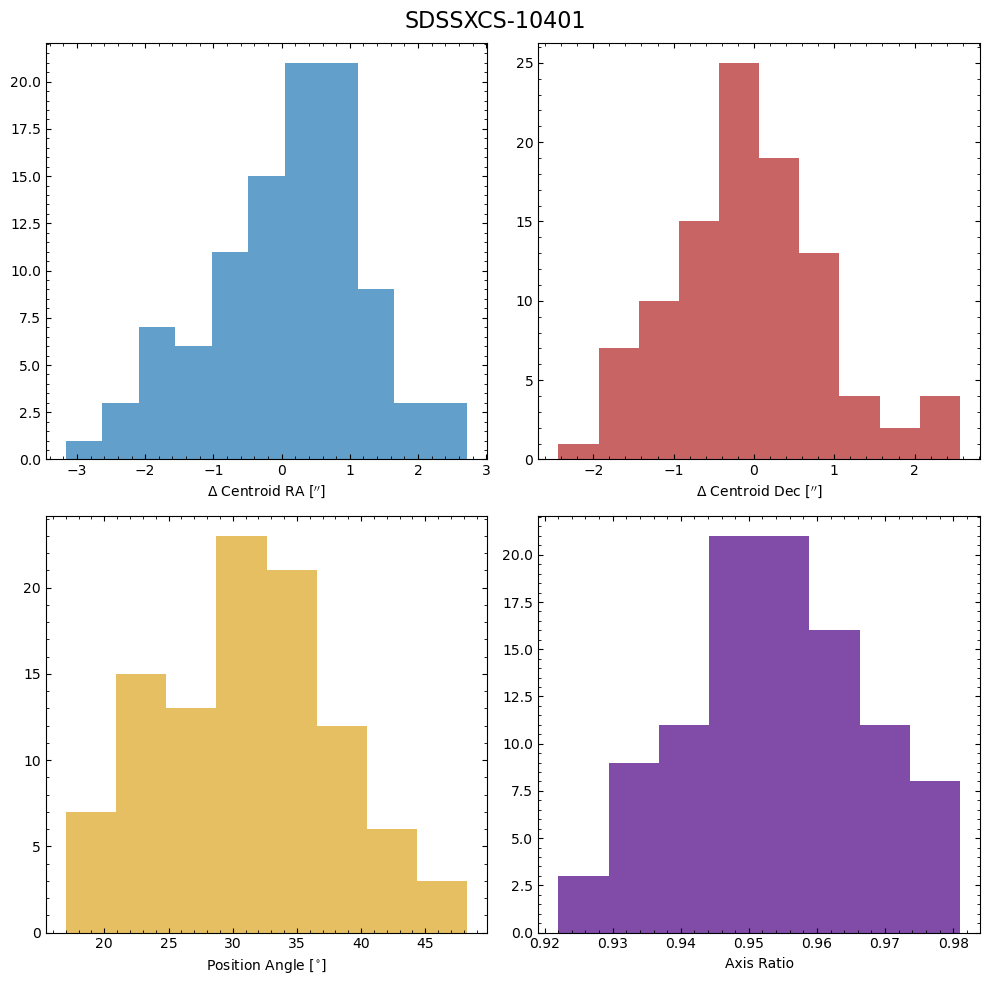

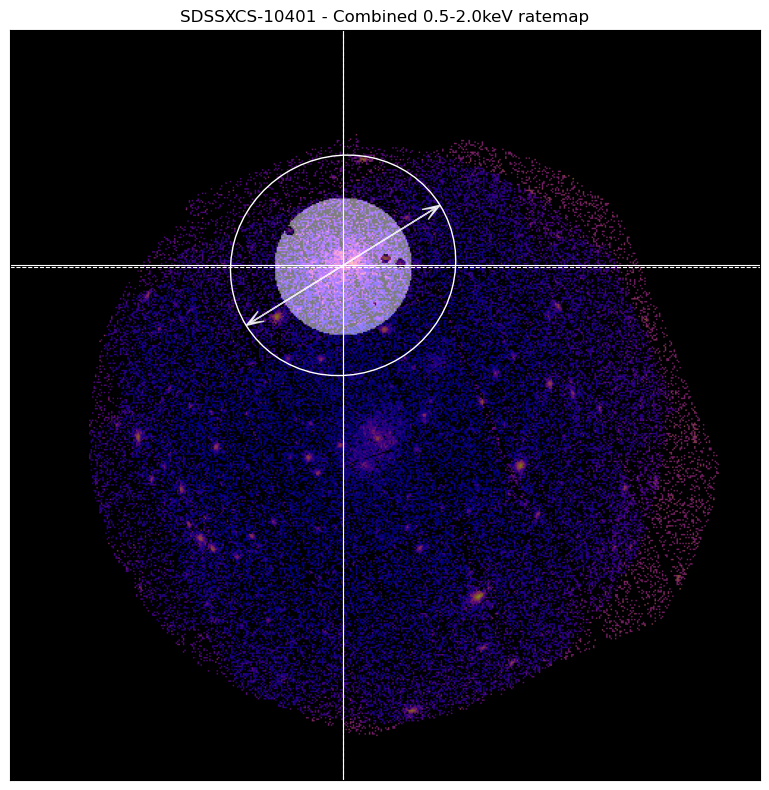

SDSSXCS-10897


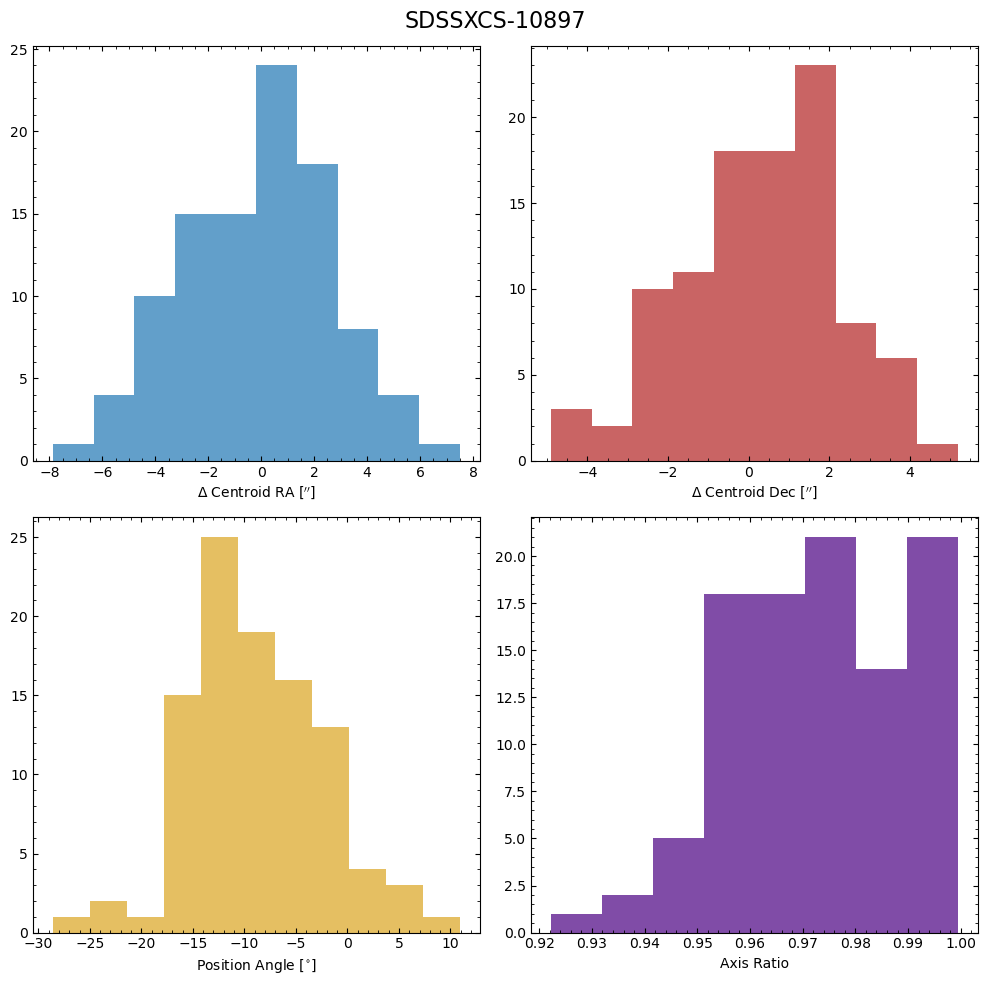

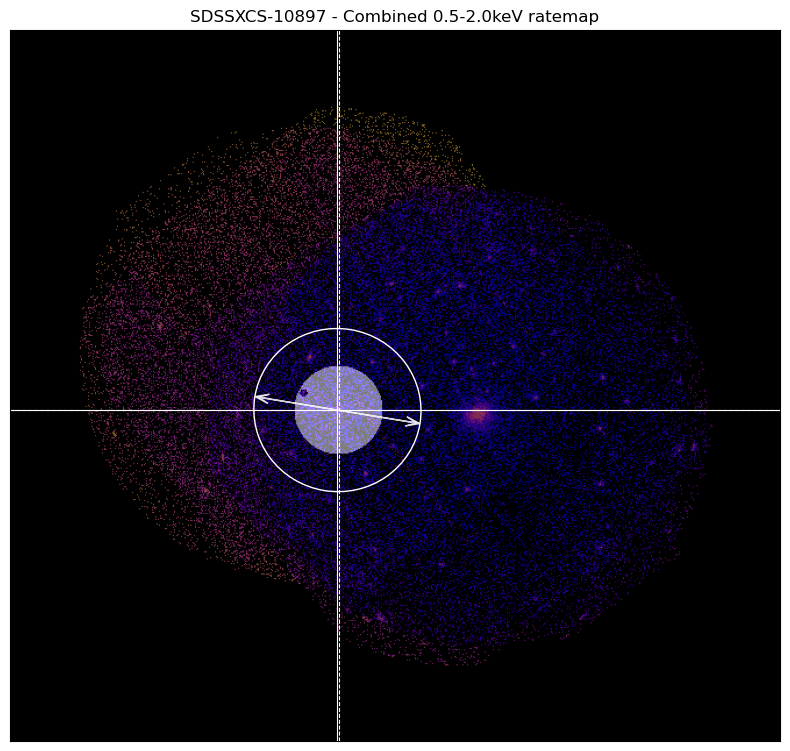

SDSSXCS-110


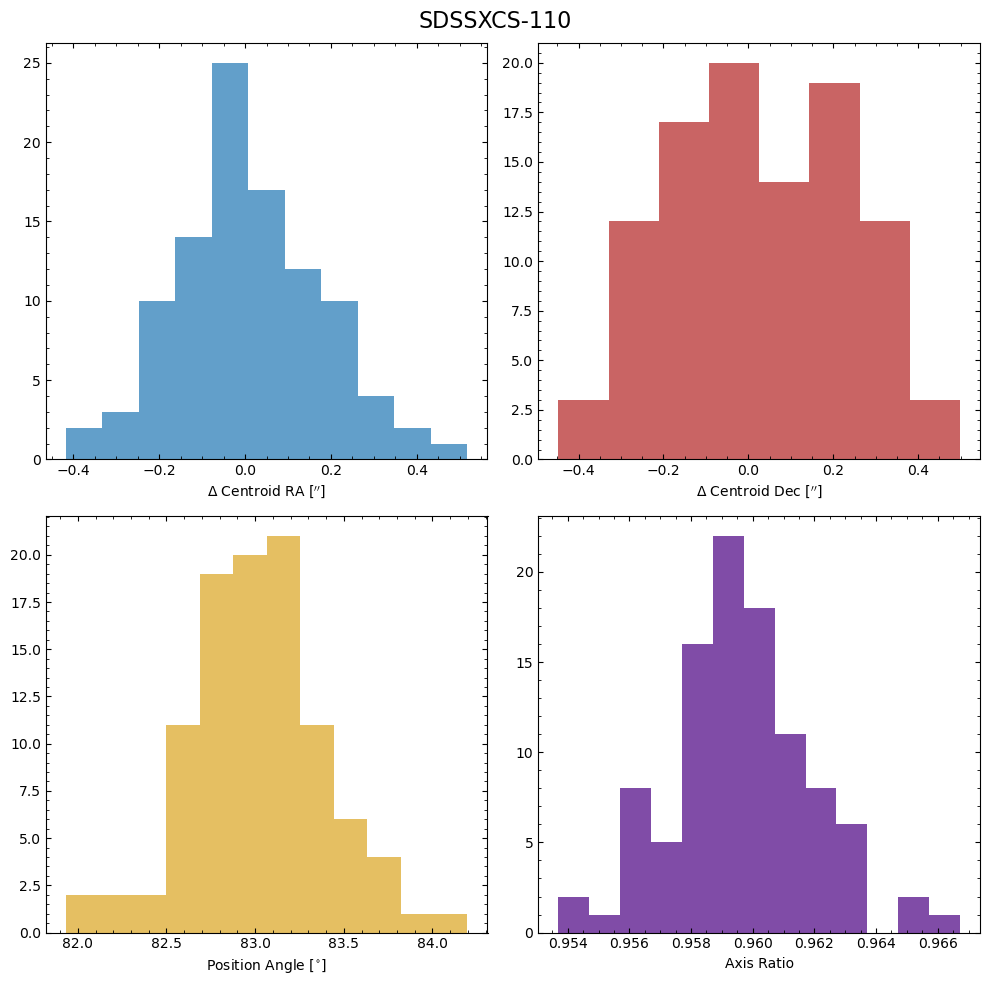

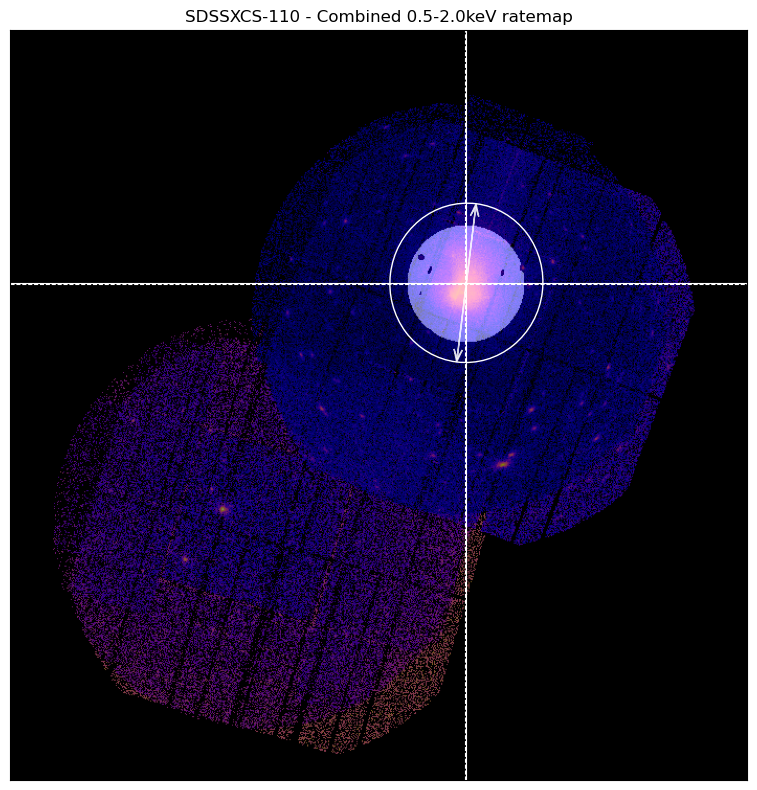

SDSSXCS-11154


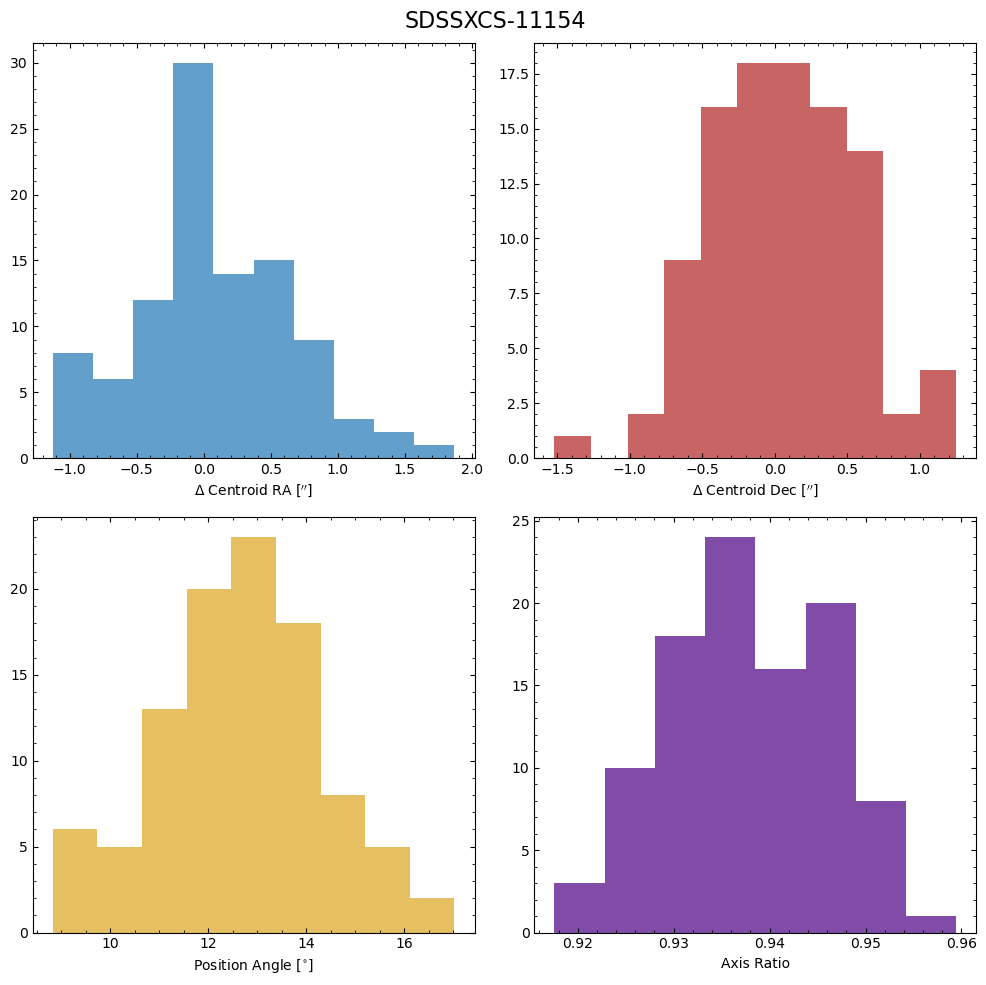

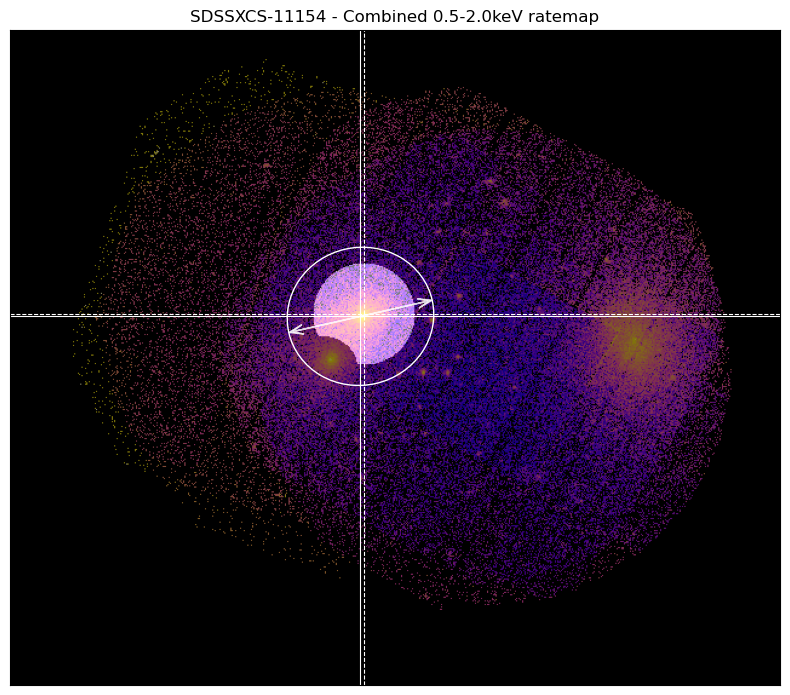

SDSSXCS-1131


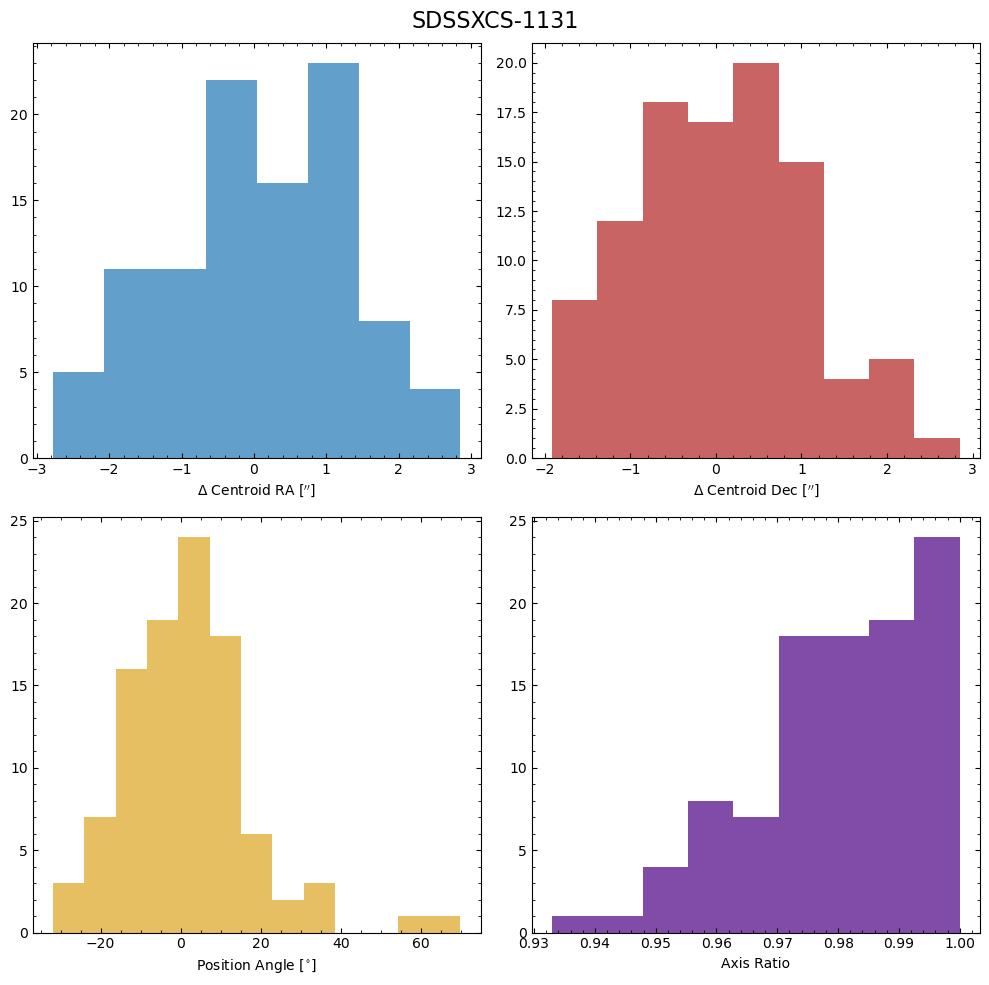

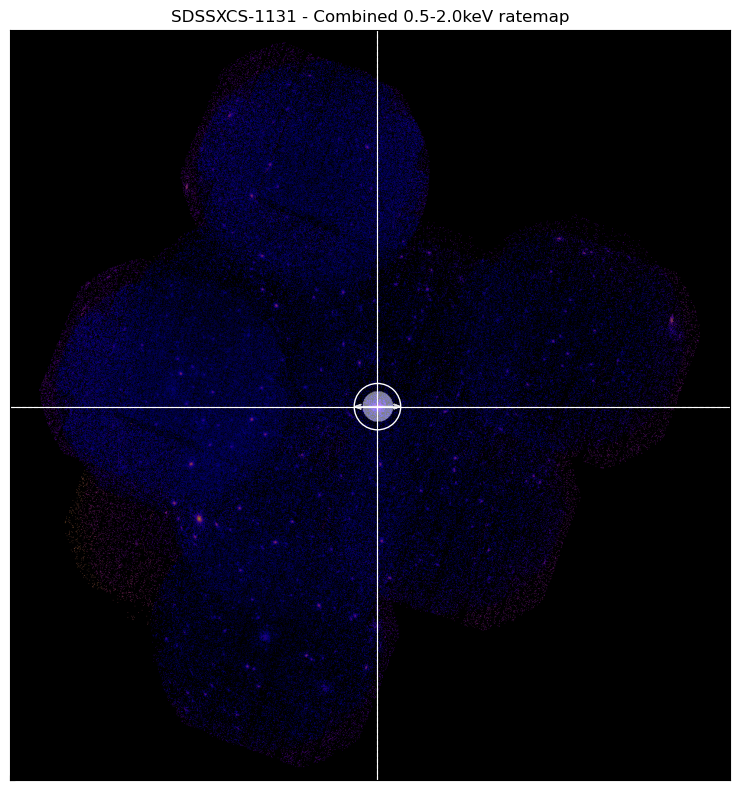

SDSSXCS-11331


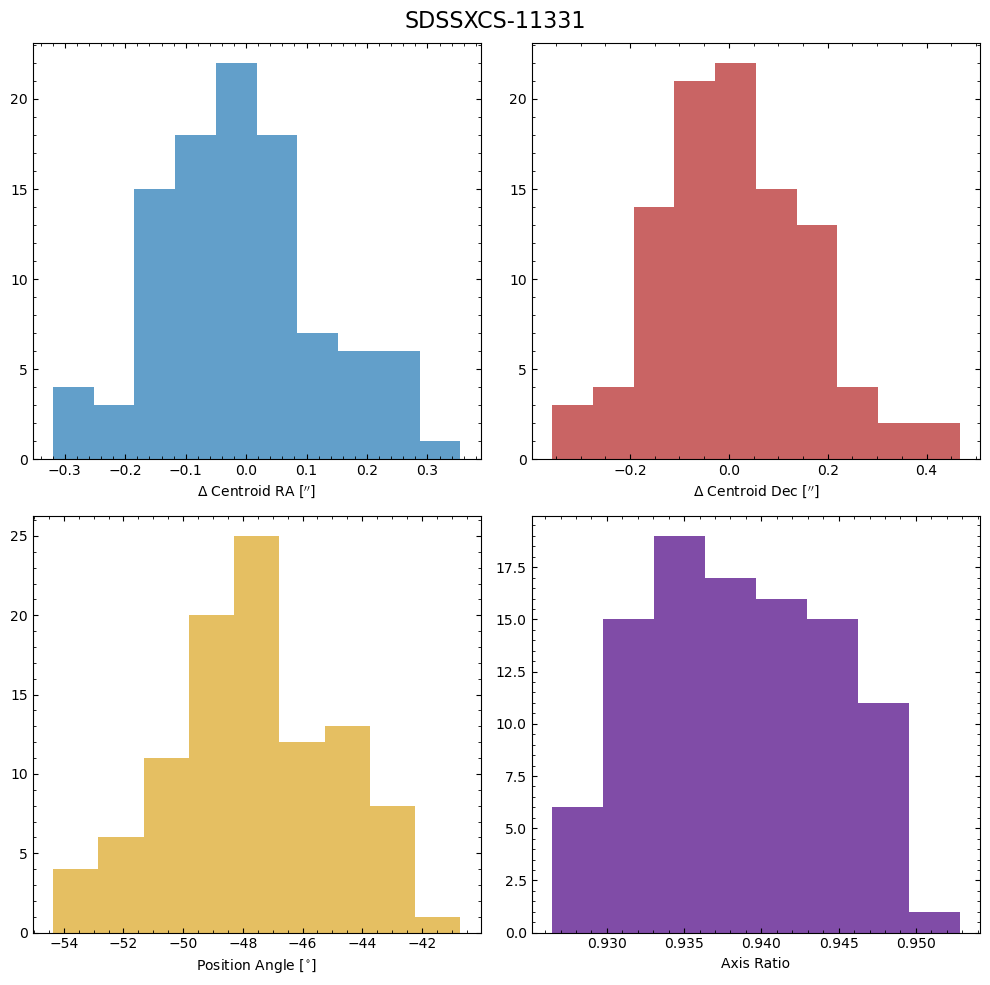

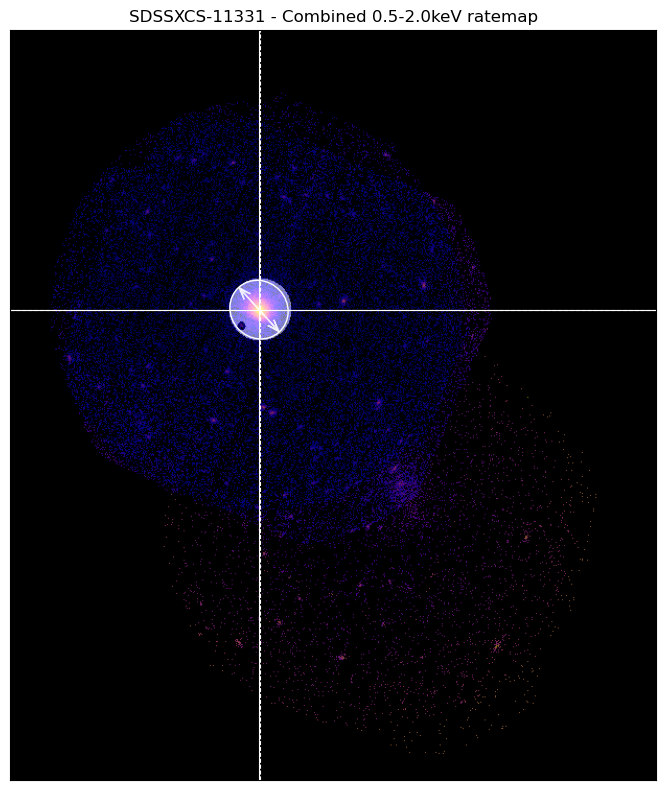

SDSSXCS-1137


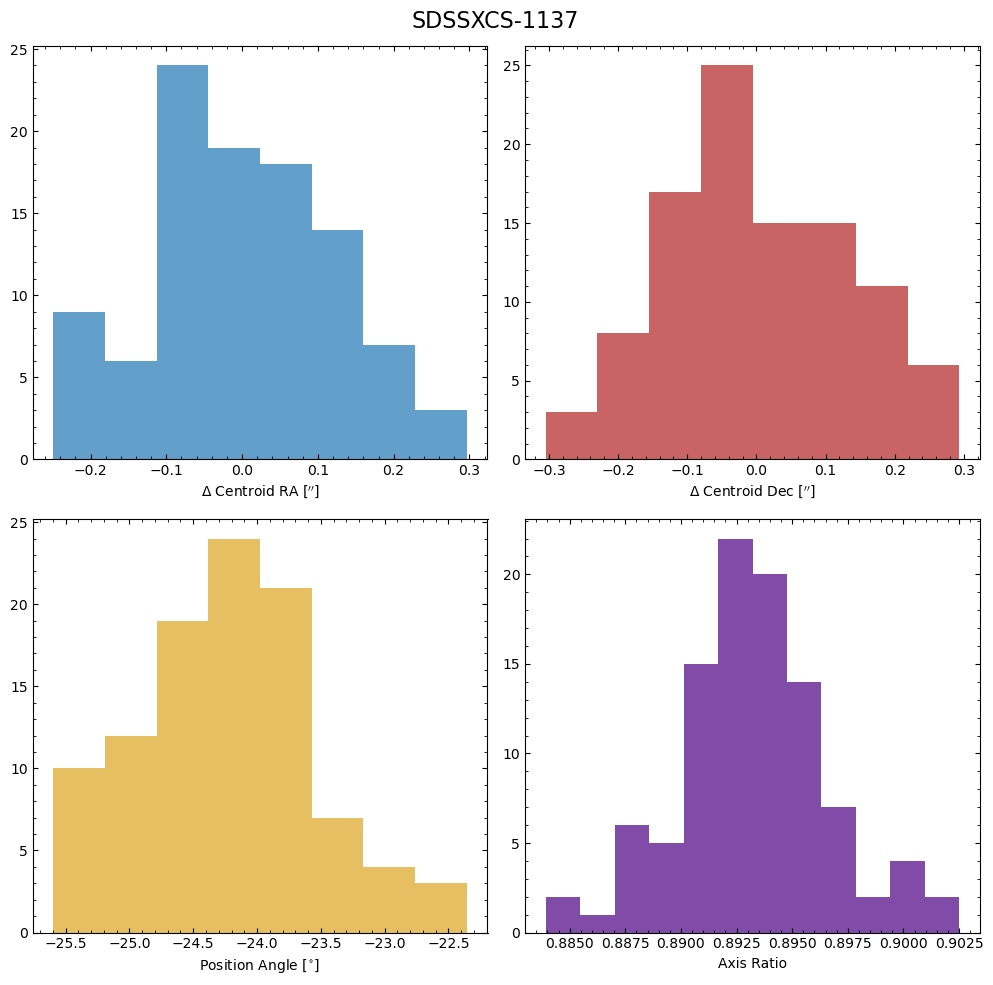

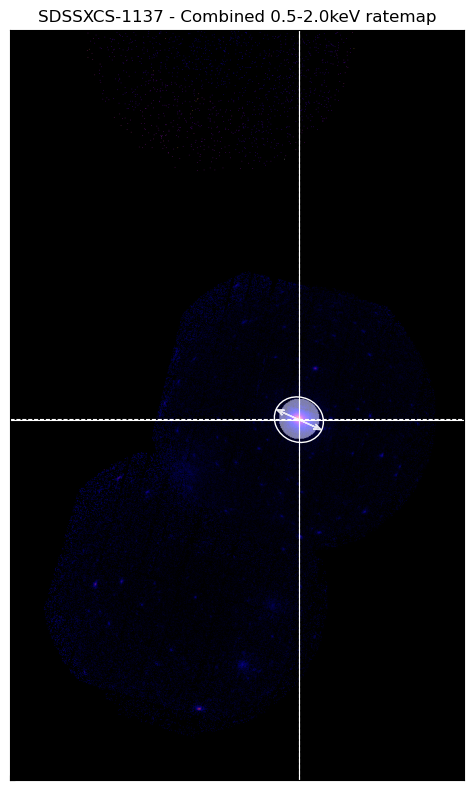

In [8]:
# The fixed aperture we're using
ap = Quantity(500, 'kpc')
# back_ap_inn = None
# back_ap_out = None
back_ap_inn = Quantity(800, 'kpc')
back_ap_out = Quantity(1000, 'kpc')

# This defines the number of times the count-rate map is resampled to calculate the statistical uncertainties
resamp = 100
# The confidence level for the extracted uncertainties
conf_level = 90

# We store our fixed-aperture measurements of centroid coordinate, position angle, and axis lengths here
fixed_ap_ra = {}
fixed_ap_dec = {}
fixed_ap_ang = {}
fixed_ap_rat = {}

# Iterating through all of our sources
for src_ind, src in enumerate(srcs):
    # This runs the centroid/PA calculation function defined near the top of the notebook. The returned position
    #  is in degrees, the PA should be defined East of North. We also return distributions of central coords, 
    #  position angle, and x/y scale, calculated from the resampled count-rate maps (the resamp variable defined
    #  how many there are)
    cur_cen, cur_pa, cur_x_scale, cur_y_scale, cur_cen_dist, cur_pa_dist, cur_x_scale_dist, \
        cur_y_scale_dist, cur_tot_mask = centroid_shape_estimate(src, ap, num_samp=resamp, back_inn_rad=back_ap_inn, 
                                                                 back_out_rad=back_ap_out) 
    
    # We can calculate confidence levels from the distributions of RA and Dec
    cen_median = np.percentile(cur_cen_dist, 50, axis=0).to('deg')
    cen_pl = np.percentile(cur_cen_dist, 50 + (conf_level/2), axis=0).to('deg') - cen_median
    cen_mi = cen_median - np.percentile(cur_cen_dist, 50 - (conf_level/2), axis=0).to('deg')

    # Same deal with the position angle, we calculate the upper and lower uncertainties at the specified
    #  confidence level 
    pa_median = np.percentile(cur_pa_dist, 50, axis=0)
    pa_pl = np.percentile(cur_pa_dist, 50 + (conf_level/2), axis=0) - pa_median
    pa_mi = pa_median - np.percentile(cur_pa_dist, 50 - (conf_level/2), axis=0)
    
    # Create distribution of axis ratios from the x and y scale distributions 
    rat_dist = np.min(np.array([(cur_x_scale_dist / cur_y_scale_dist), (cur_y_scale_dist / cur_x_scale_dist)]), 
                      axis=0)
    # Then we calculate the uncertainties the same way
    rat_median = np.percentile(rat_dist, 50, axis=0)
    rat_pl = np.percentile(rat_dist, 50 + (conf_level/2), axis=0) - rat_median
    rat_mi = rat_median - np.percentile(rat_dist, 50 - (conf_level/2), axis=0)
    
    # Store the results of this analysis in dictionaries for later
    fixed_ap_ra[src.name] = [cen_median[0], cen_mi[0], cen_pl[0]]
    fixed_ap_dec[src.name] = [cen_median[1], cen_mi[1], cen_pl[1]]
    fixed_ap_ang[src.name] = [pa_median, pa_mi, pa_pl]
    fixed_ap_rat[src.name] = [min([(cur_x_scale/cur_y_scale), (cur_y_scale/cur_x_scale)]), rat_mi, rat_pl]
    
    # We make some crude histograms of the output distributions of the different values we've measured, so
    #  they aren't lost forever - they will be saved to disk as well
    fig, ax_arr = plt.subplots(2, 2, figsize=(10, 10))
    
    for ax_ind, ax in np.ndenumerate(ax_arr):
        ax.minorticks_on()
        ax.tick_params(which='both', direction='in', top=True, right=True)
    
    # We just plot the histograms, nothing fancy - we also leave the bins to auto
    ax_arr[0, 0].hist((cur_cen_dist[:, 0]-cur_cen[0]).to("arcsec").value, bins='auto', 
                      histtype='stepfilled', label='RA', color='tab:blue', alpha=0.7)
    ax_arr[0, 0].set_xlabel(r"$\Delta$ Centroid RA [$^{\prime\prime}$]")
    
    ax_arr[0, 1].hist((cur_cen_dist[:, 1]-cur_cen[1]).to("arcsec").value, bins='auto', 
                      histtype='stepfilled', label='Dec', color='firebrick', alpha=0.7)
    ax_arr[0, 1].set_xlabel(r"$\Delta$ Centroid Dec [$^{\prime\prime}$]")
    
    ax_arr[1, 0].hist(cur_pa_dist, bins='auto', histtype='stepfilled', label='PA', 
                      color='goldenrod', alpha=0.7)
    ax_arr[1, 0].set_xlabel(r"Position Angle [$^{\circ}$]")
    
    ax_arr[1, 1].hist(rat_dist, bins='auto', histtype='stepfilled', label='Axis Ratio', 
                      color='indigo', alpha=0.7)
    ax_arr[1, 1].set_xlabel(r"Axis Ratio")
    
    # Add an overall title containing the name of the cluster
    plt.suptitle(src.name, fontsize=16)
    plt.tight_layout()
    # All histograms are saved
    file_name = "{n}_xmm_centroid_{a}kpc_prop_dists.pdf".format(n=src.name, a=ap.to('kpc').value.astype(int))
    plt.savefig(fix_ap_dist_path + file_name)
    # Only the first ten are shown here, to keep the size of the notebook down
    if src_ind < 10: 
        print(src.name)  
        plt.show()
    plt.close('all')
    
    # Fetch the combined ratemap
    cur_rt = src.get_combined_ratemaps()
    
    # Start constructing the visualisation
    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    # We use the 'get_view' method here to return the axis populated with our nicely formatted ratemap data (as 
    #  well as with centroid as solid cross-hair and start position as dashed cross-hair), and then we will
    #  add to it.
    cur_rt.get_view(ax, Quantity([cur_cen, src.ra_dec]))

    # We also want to add a layer that makes it obvious (though not intrusively so) which parts of the
    #  data have been used for this analysis
    plt.sca(ax)
    plt.imshow(cur_tot_mask, alpha=0.5, cmap='binary_r', origin='lower')
    
    # Convert the centroid position to pixels, so we use it to define an ellipse to overplot
    cur_cen_pix = cur_rt.coord_conv(cur_cen, 'pix')
    # The ellipse is set up using the pixel centre, abritrarily scaled up x and y axis lengths (the ratio
    #  of them is more useful than the actual values honestly), and the position angle
    scale_fac = 8
    ell = Ellipse(cur_cen_pix.value, cur_x_scale*scale_fac, cur_y_scale*scale_fac, angle=pa_median, fc='none', 
                  ec='white')
    ax.add_patch(ell)
        
    # Here we wish to add a line along the major axis of the ellipse, to unambiguously indicate the rotation
    #  angle we measured. We separate the arrow into two halves, as we're not yet sure whether this figure is 
    #  clearer with a full major axis or just a semi-major axis line.
    # This sets the width of the actual line
    line_width = 0.2
    # We also set the alpha here
    alpha = 0.8
    
    # We wish to draw along the major axis, so we setup the coordinates and then use a rotation
    #  matrix to match the rotation of the ellipse - as the FancyArrow class wants a dx and dy we
    #  do not translate the coordinates to the ellipse's position here
    rot_mat = np.array([[np.cos((pa_median) * (np.pi/180)), -1 * np.sin((pa_median) * (np.pi/180))], 
                        [np.sin((pa_median) * (np.pi/180)), np.cos((pa_median) * (np.pi/180))]])
    line_stop_dx, line_stop_dy = (rot_mat @ np.array([(cur_x_scale*scale_fac)/2, 0]))
    
    # Setup the patch with our start and end coords, as well as the appearance settings
    line = FancyArrow(*cur_cen_pix.value, line_stop_dx, line_stop_dy, color='white', head_width=8, 
                      length_includes_head=True, overhang=0.7, width=line_width, alpha=alpha, )    
    # Then add the patch
    ax.add_patch(line)
    
    # Repeat the process but flipped 180 degrees
    rot_mat = np.array([[np.cos((pa_median+180) * (np.pi/180)), -1 * np.sin((pa_median+180) * (np.pi/180))], 
                        [np.sin((pa_median+180) * (np.pi/180)), np.cos((pa_median+180) * (np.pi/180))]])
    line_stop_dx, line_stop_dy = (rot_mat @ np.array([(cur_x_scale*scale_fac)/2, 0]))
    line = FancyArrow(*cur_cen_pix.value, line_stop_dx, line_stop_dy, color='white', head_width=8,
                      length_includes_head=True, overhang=0.7, width=line_width, alpha=alpha)
    ax.add_patch(line)
    
    plt.tight_layout()
    
    # All visualisations are saved to disk
    file_name = "{n}_xmm_centroid_{a}kpc_search_vis.pdf".format(n=src.name, a=ap.to('kpc').value.astype(int))
    plt.savefig(centroid_posang_vis_path + file_name)
    
    # We only display a few visualisations, in order to avoid making the Jupyter Notebook too large 
    #  to be rendered by the GitHub website
    if src_ind < 10:
        plt.show()
    plt.close('all')

### Saving the fixed aperture centroids, angles, and axis ratios

Here we construct a save file containing the just measured centroid positions, angles, and axis ratios (though we measured some form of axis length, its actual physical meaning is limited, the axis ratios are more directly useful).

In [9]:
# Somewhat overkill, but I still remember the days of unordered dictionaries in Python and I remain paranoid, 
#  this reads the centroid positions into a single quantity (easier to add to a dataframe)
out_ras = Quantity([Quantity(fixed_ap_ra[n]) for n in srcs.names]).round(5)
out_decs = Quantity([Quantity(fixed_ap_dec[n]) for n in srcs.names]).round(5)
out_angs = np.array([fixed_ap_ang[n] for n in srcs.names]).round(4)
out_ax_rat = np.array([fixed_ap_rat[n] for n in srcs.names]).round(4)

out_data = np.concatenate([srcs.names[..., None], out_ras.value, out_decs.value, out_angs, out_ax_rat], 
                          axis=1)
out_cols = ['name', 'cent_ra', 'cent_ra-', 'cent_ra+', 'cent_dec', 'cent_dec-', 'cent_dec+', 
            'position_angle', 'position_angle-', 'position_angle+', 'ax_ratio', 'ax_ratio-', 'ax_ratio+']
out_df = pd.DataFrame(out_data, columns=out_cols)

file_name = "xmm_{a}kpc_centroid.csv".format(n=src.name, a=ap.to('kpc').value.astype(int))
out_df.to_csv(coords_morph_out_path + file_name, index=False)
out_df

,name,cent_ra,cent_ra-,cent_ra+,cent_dec,cent_dec-,cent_dec+,position_angle,position_angle-,position_angle+,ax_ratio,ax_ratio-,ax_ratio+
0,SDSSXCS-1018,4.40764,0.00026,0.00017,-0.87681,0.00018,0.00021,-65.5222,6.4147,6.1093,0.9508,0.0187,0.0104
1,SDSSXCS-10223,327.85349,0.00029,0.00044,-5.44583,0.00038,0.00052,44.9609,3.9122,3.6388,0.8647,0.0129,0.0162
2,SDSSXCS-103,117.70449,0.00018,0.00026,17.69662,0.00018,0.00018,42.8605,1.5522,1.8325,0.8588,0.0093,0.009
3,SDSSXCS-10401,179.61552,0.00057,0.00042,26.49677,0.00042,0.00048,31.8178,11.3388,10.2383,0.9536,0.0198,0.0229
4,SDSSXCS-10897,170.23093,0.00138,0.00113,43.30675,0.00095,0.00075,-9.2918,8.3693,10.3758,0.9745,0.0241,0.0239
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,SDSSXCS-913,339.91377,0.00043,0.00039,-5.72318,0.00039,0.00039,12.3023,8.6486,11.647,0.9631,0.0349,0.0226
146,SDSSXCS-9258,159.50975,0.00101,0.00096,41.77216,0.00076,0.00082,-38.3266,18.1042,18.5891,0.9649,0.0255,0.0188
147,SDSSXCS-9313,189.07631,0.00031,0.0003,28.9847,0.00024,0.0003,-50.136,17.9669,17.9198,0.9739,0.0187,0.015
148,SDSSXCS-944,29.28351,0.00045,0.00036,-5.87373,0.0005,0.00049,-29.7035,6.0741,3.8225,0.9257,0.0159,0.0157


## Common morphology metrics

In this section, we measure some common, and simple, metrics that describe the morphology of the galaxy clusters in our sample.

### Measuring standard centroid shift ($w$)

First of all, we use our centroid-measuring capability to define the 'centroid shift' of each clusters. Centroid shift is defined as, 

$w = [\dfrac{1}{n-1} \Sigma(\Delta_{i} - \langle\Delta\rangle)^{2}]^{0.5}\dfrac{1}{R_{ap}}$,

where we use $n=20$ and $R_{ap}=500$ kpc, which are commonly used values. This shift measurement helps to summarise how disturbed the clusters are, with higher values indicating larger deviations of the centroid from the peak.

In [10]:
frac_ap = np.linspace(0.05, 1, 20)
seq_aps = frac_ap*Quantity(500, 'kpc')
seq_aps

<Quantity [ 25.,  50.,  75., 100., 125., 150., 175., 200., 225., 250.,
           275., 300., 325., 350., 375., 400., 425., 450., 475., 500.] kpc>

In [11]:
# This defines the number of times the count-rate map is resampled to calculate the statistical uncertainties
resamp = 100
# The confidence level for the extracted uncertainties
conf_level = 90

back_ap_inn = Quantity(800, 'kpc')
back_ap_out = Quantity(1000, 'kpc')

cen_shifts = []
cen_shift_dists = []
stand_cents = {}
stand_cent_dists = {}

for src in srcs:
    stand_cents[src.name] = []
    stand_cent_dists[src.name] = []
    
    try:
        rel_peak_row = sdssxcs_samp[sdssxcs_samp['name'] == src.name].iloc[0]
        rel_peak = Quantity(rel_peak_row[['peak_ra', 'peak_dec']], 'deg')
    except:
        print(src.name)
        cen_shifts.append([np.nan, np.nan, np.nan])
        continue

    print(src.name)
    print(rel_peak)
    
    shift_cens, shift_angs, shift_xs, shift_ys, shift_cen_dists, shift_pa_dists, \
        shift_cur_x_dists, shift_cur_y_dists, shift_tot_mask = centroid_shape_estimate(src, seq_aps, num_samp=resamp, 
                                                                                       back_inn_rad=back_ap_inn, 
                                                                                       back_out_rad=back_ap_out, 
                                                                                       cent_coord=rel_peak)
            
    rel_cents = Quantity(shift_cens)
    stand_cents[src.name].append(rel_cents)
    
    ang_dists = haversine(rel_peak[0], rel_peak[1], rel_cents[:, 0], rel_cents[:, 1])
    prop_dists = src.convert_radius(ang_dists, 'kpc')
    mean_dist = np.nanmean(prop_dists)

    # cen_shift = np.sqrt((1/(len(frac_ap)-1))*((prop_dists - mean_dist)**2).sum()) * (1/seq_aps[-1])
    
    # This uses the N realisations of the centroid that we calculated to estimate the uncertainty on
    #  the centroid shift
    cen_dists = Quantity(shift_cen_dists)
    stand_cent_dists[src.name].append(cen_dists)
    prop_cent_diff_dist = src.convert_radius(haversine(rel_peak[0], rel_peak[1], cen_dists[:, :, 0], 
                                                       cen_dists[:, :, 1]), 'kpc')
    expec_diff = np.nanmean(prop_cent_diff_dist, axis=0)
    cen_shift_dist = (np.sqrt((1/(len(frac_ap)-1))*((prop_cent_diff_dist - expec_diff)**2).sum(axis=0)) * 
                      (1/seq_aps[-1]))
    
    cen_shift_median = np.nanpercentile(cen_shift_dist, 50, axis=0)
    cen_shift_pl = np.nanpercentile(cen_shift_dist, 50 + (conf_level/2), axis=0) - cen_shift_median
    cen_shift_mi = cen_shift_median - np.nanpercentile(cen_shift_dist, 50 - (conf_level/2), axis=0)
    
    # Append the calculated values and the uncertainties, as well as the whole distribution
    cen_shifts.append([cen_shift_median, cen_shift_mi, cen_shift_pl])
    cen_shift_dists.append(cen_shift_dist)

cen_shifts = np.array(cen_shifts)
cen_shift_dist = np.array(cen_shift_dist)

SDSSXCS-1018
[ 4.40815857 -0.88121505] deg


SDSSXCS-10223
[327.84630135  -5.44777997] deg


SDSSXCS-103
[117.70116066  17.70490686] deg


SDSSXCS-10401
[179.6078868   26.49921885] deg


SDSSXCS-10897
[170.2246041   43.30277258] deg


...

SDSSXCS-913
[339.91133718  -5.72388785] deg


SDSSXCS-9258
[159.50473806  41.76405555] deg


SDSSXCS-9313
[189.08423686  28.98661083] deg


SDSSXCS-944
[29.26864089 -5.88041368] deg


SDSSXCS-9803
[135.15363689  20.89466624] deg


### Measuring concentration parameter ($c$)

We also measure the 'concentration parameter', which is even simpler than the centroid shift (but highly useful) - it is just the ratio of flux within a 100 kpc aperture centered on the core of the cluster, and the flux within a 500 kpc aperture centered on the same spot:

$c = \dfrac{F_{\leq100\rm{kpc}}}{F_{\leq500\rm{kpc}}}$

Interpreting it is quite easy, as it should be fairly obvious that cool-core clusters (with denser, brighter, cores) will have higher concentration values than disturbed clusters.

<!-- $c = \dfrac{\sum\limits_{x,y}^{R\leq100\rm{kpc}}}{\sum\limits_{x,y}^{R\leq500\rm{kpc}}}$ -->

In [12]:
# This defines the number of times the count-rate map is resampled to calculate the statistical uncertainties
resamp = 100
# The confidence level for the extracted uncertainties
conf_level = 90

back_ap_inn = Quantity(800, 'kpc')
back_ap_out = Quantity(1000, 'kpc')

concs = []
for src in srcs:
    try:
        # TODO DECIDE ON WHETHER TO USE PEAK OR CENTROID
        rel_peak_row = sdssxcs_samp[sdssxcs_samp['name'] == src.name].iloc[0]
        rel_peak = Quantity(rel_peak_row[['peak_ra', 'peak_dec']], 'deg')

        cur_rt = src.get_combined_ratemaps()

        back_mask = src.get_custom_mask(back_ap_out, back_ap_inn, remove_interlopers=True, 
                                        central_coord=rel_peak)    

        data_cp = cur_rt.data.copy()

        back_area = (back_mask * cur_rt.sensor_mask).sum()
        back_rt = np.sum(data_cp*back_mask)/back_area
        data_cp = data_cp - back_rt
        data_cp[data_cp < 0] = 0
        
        cont_mask = src.get_interloper_mask()
        ap100kpc_mask = src.get_custom_mask(Quantity(100, 'kpc'), remove_interlopers=True, 
                                            central_coord=rel_peak)
        ap500kpc_mask = src.get_custom_mask(Quantity(500, 'kpc'), remove_interlopers=True, 
                                            central_coord=rel_peak)

        conc = (data_cp*ap100kpc_mask).sum() / (data_cp*ap500kpc_mask).sum()
        
        rng = np.random.default_rng()
        resamp_data = np.repeat((data_cp*cont_mask)[:, :, np.newaxis], resamp, axis=2)
        resamp_data = rng.poisson(resamp_data*cur_rt.expmap.data[..., None])/cur_rt.expmap.data[..., None]
        resamp_data[np.isnan(resamp_data)] = 0
        
        conc_dist = (resamp_data*ap100kpc_mask[..., None]).sum(axis=(0, 1)) / \
            (resamp_data*ap500kpc_mask[..., None]).sum(axis=(0, 1))
        
        conc_median = np.nanpercentile(conc_dist, 50, axis=0)
        conc_pl = np.nanpercentile(conc_dist, 50 + (conf_level/2), axis=0) - conc_median
        conc_mi = conc_median - np.nanpercentile(conc_dist, 50 - (conf_level/2), axis=0)
        
        concs.append([conc_median, conc_mi, conc_pl])        
        
    except IndexError:
        concs.append([np.nan, np.nan, np.nan])

concs = np.array(concs)

### Classifying relaxed and disturbed with $c-w$ plane limits from [Lovisari et al. 2017](https://ui.adsabs.harvard.edu/abs/2017ApJ...846...51L/abstract)

First we combine the morphology measurements into a dataframe:

In [13]:
out_data = np.concatenate([srcs.names[..., None], cen_shifts.round(4), concs.round(4)], 
                          axis=1)
out_cols = ['name', 'cen_shift', 'cen_shift-', 'cen_shift+', 'concentration', 
            'concentration-', 'concentration+']
out_morph_df = pd.DataFrame(out_data, columns=out_cols)

# Makes sure that all the morphology metrics are floats
out_morph_df[['cen_shift', 'cen_shift-', 'cen_shift+', 'concentration', 'concentration-', 'concentration+']] = out_morph_df[['cen_shift', 'cen_shift-', 'cen_shift+', 'concentration', 'concentration-', 'concentration+']].astype(float)

Use the $c-w$ plane limits that Lovisari et al. found were most effective at selecting relaxed galaxy clusters - we also display how many of each type there are:

In [14]:
rel_bool = (out_morph_df['concentration'] > 0.15) & (out_morph_df['cen_shift'] < 2.1e-2)
# There shouldn't be NaN values for these morphology metrics, but there have been in the past so better to be safe
rel_bool[(out_morph_df['concentration'].isnull()) | (out_morph_df['cen_shift'].isnull())] = np.nan
# Add values to the dataframe 
out_morph_df['lovisari2017_relaxed'] = rel_bool

# How many of each classification are there?
out_morph_df['lovisari2017_relaxed'].value_counts()

lovisari2017_relaxed
False    88
True     62
Name: count, dtype: int64

### Saving morphological parameters

Now we're going to write the dataframe to disk:

In [15]:
file_name = "xmm_centshift_concentration.csv"
out_morph_df.to_csv(coords_morph_out_path + file_name, index=False)
out_morph_df

,name,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+,lovisari2017_relaxed
0,SDSSXCS-1018,0.0256,0.0016,0.0017,0.2855,0.0055,0.0056,False
1,SDSSXCS-10223,0.0316,0.0022,0.0026,0.1876,0.0058,0.0082,False
2,SDSSXCS-103,0.0299,0.0024,0.0017,0.0875,0.0031,0.0028,False
3,SDSSXCS-10401,0.0249,0.0034,0.0033,0.1687,0.0070,0.0067,False
4,SDSSXCS-10897,0.0150,0.0044,0.0071,0.0768,0.0115,0.0129,False
...,...,...,...,...,...,...,...,...
145,SDSSXCS-913,0.0117,0.0036,0.0048,0.1714,0.0117,0.0125,True
146,SDSSXCS-9258,0.0196,0.0032,0.0036,0.1027,0.0072,0.0086,False
147,SDSSXCS-9313,0.0430,0.0034,0.0030,0.1543,0.0051,0.0050,False
148,SDSSXCS-944,0.0484,0.0035,0.0025,0.1141,0.0068,0.0065,False


## Concentration - centroid shift plane visualizations

In [16]:
# Median value of the centroid shift distribution of our sample
cs_med = np.nanmedian(out_morph_df['cen_shift'].values)

# And the same for concentration
conc_med = np.nanmedian(out_morph_df['concentration'].values)

### Concentration & centroid shift distributions

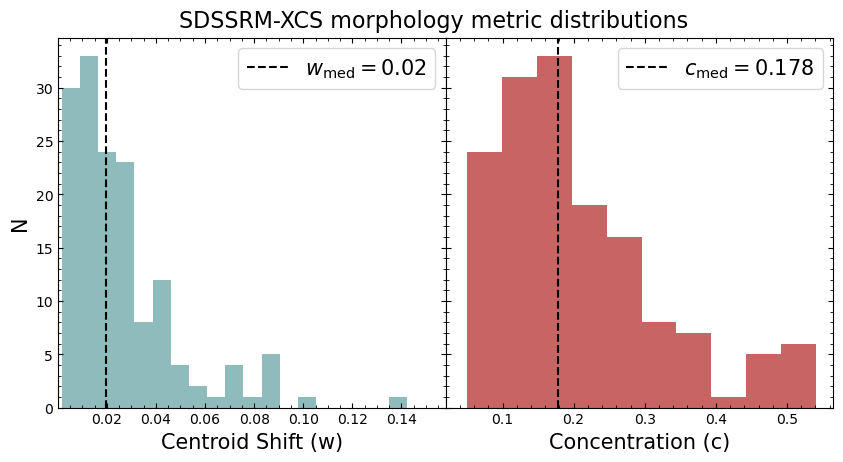

In [17]:
fig, ax_arr = plt.subplots(ncols=2, figsize=(10, 4.8), sharey=True)
fig.subplots_adjust(wspace=0)

# Set the ticks up as we like them
for ax in ax_arr:
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

# Plot the centroid shift distribution
ax = ax_arr[0]
plt.sca(ax)
plt.hist(out_morph_df['cen_shift'], bins='auto', color='cadetblue', alpha=0.7)
# Add the median centroid shift value
plt.axvline(cs_med, color='black', linestyle='dashed', label=r'$w_{\rm{med}}=' + str(round(cs_med, 3)) + "$")
# Limit and label the axes
plt.xlim(0.0002, 0.158)
plt.xlabel('Centroid Shift (w)', fontsize=15)
plt.ylabel('N', fontsize=15)
# This axes' legend
plt.legend(fontsize=15)

# Plot the concentration distribution
ax = ax_arr[1]
plt.sca(ax)
plt.hist(out_morph_df['concentration'], bins='auto', color='firebrick', alpha=0.7)
# Add the median concentration value
plt.axvline(conc_med, color='black', linestyle='dashed', label=r'$c_{\rm{med}}=' + str(round(conc_med, 3)) + "$")
plt.xlim(0.02)
plt.xlabel('Concentration (c)', fontsize=15)
# This axes' legend
plt.legend(fontsize=15)
plt.suptitle("SDSSRM-XCS morphology metric distributions", fontsize=16, y=0.94)

plt.savefig("../../outputs/figures/icm_morphology/distributions_concentration_censhift.pdf", bbox_inches='tight')
plt.show()

### Concentration parameter vs centroid shift

We plot the concentration parameters and centroid shifts that we have measured for our sample - this is often used to explore how relaxed a sample of galaxy clusters is - we also overplot values proposed by [Cassano et al. (2010)](https://ui.adsabs.harvard.edu/abs/2010A%26A...509A..68C/abstract) to separate relaxed and disturbed clusters (high values of concentration parameter and low values of centroid shift indicate relaxation), as well as the median values of our distributions:

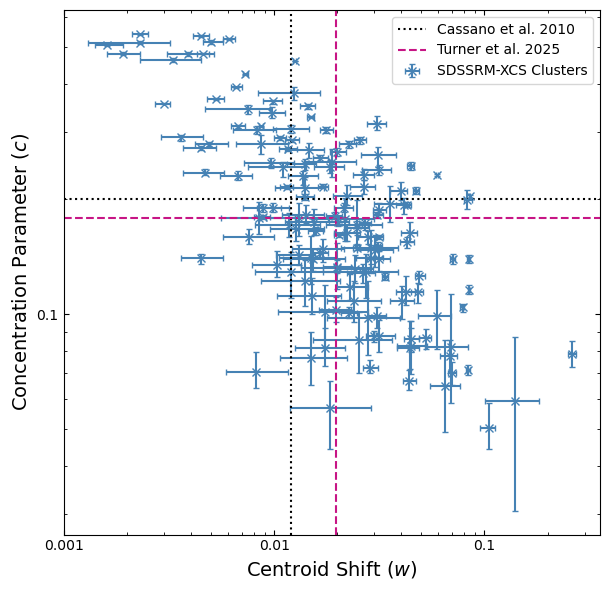

In [18]:
plt.figure(figsize=(6.2, 6))

plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.errorbar(out_morph_df['cen_shift'].values, out_morph_df['concentration'].values, 
             xerr=out_morph_df[['cen_shift-', 'cen_shift+']].values.T, 
             yerr=out_morph_df[['concentration-', 'concentration+']].values.T, 
             fmt='x', color='steelblue', label='SDSSRM-XCS Clusters', capsize=2) 

# Cassano et al. medians maybe?
plt.axvline(0.012, color='black', linestyle='dotted', label="Cassano et al. 2010")
plt.axhline(0.2, color='black', linestyle='dotted')

# Our medians
plt.axvline(cs_med, color='mediumvioletred', linestyle='dashed', label="Turner et al. 2025")
plt.axhline(conc_med, color='mediumvioletred', linestyle='dashed')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r"Centroid Shift ($w$)", fontsize=14)
plt.ylabel(r"Concentration Parameter ($c$)", fontsize=14)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.legend(loc='best')
plt.tight_layout()
plt.savefig("../../outputs/figures/icm_morphology/concentration_censhift.pdf")
plt.show()

### Relaxed and unrelaxed concentration parameter vs centroid shift 

Make a visualization of the plane with the relaxed and not-relaxed systems shown in different colours:

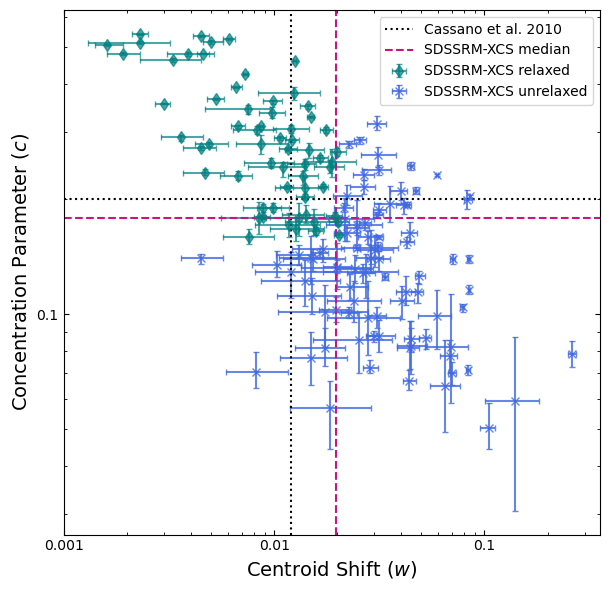

In [19]:
# There should not be NaN morphology values in this dataframe, but we have seen that in the past whilst developing
#  these analyses - as such we will filter here to make sure there aren't any exceptions - we'll also show a warning
#  though as an indicator to whoever is running the notebook
nonan_out_morph_df = out_morph_df[~out_morph_df['lovisari2017_relaxed'].isnull()].reset_index(drop=True)
# Make sure that the relaxed column type is bool
nonan_out_morph_df['lovisari2017_relaxed'] = nonan_out_morph_df['lovisari2017_relaxed'].astype(bool)
# Show the warning, if there needs to be one
if len(nonan_out_morph_df) != len(out_morph_df):
    warn("There are NaN morphology values!")
    
# We find systems that (per the Lovisari limts in Table 2 of their paper) are relaxed
sdssxcs_samp_app_relaxed = nonan_out_morph_df[nonan_out_morph_df['lovisari2017_relaxed']]
# And define everything else as 'not relaxed' (which doesn't necessarily mean disturbed, at least in my head - it 
#  isn't as simple as a cluster being one thing or another)
sdssxcs_samp_app_not_relaxed = nonan_out_morph_df[~nonan_out_morph_df['lovisari2017_relaxed']]

# Making another version of the figure in the morphology notebook, might well transplant this there
plt.figure(figsize=(6.2, 6))

plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

# First the apparently relaxed
plt.errorbar(sdssxcs_samp_app_relaxed['cen_shift'], sdssxcs_samp_app_relaxed['concentration'], 
             xerr=sdssxcs_samp_app_relaxed[['cen_shift-', 'cen_shift+']].values.T, 
             yerr=sdssxcs_samp_app_relaxed[['concentration-', 'concentration+']].values.T, 
             fmt='d', color='teal', label='SDSSRM-XCS relaxed', 
             capsize=2, alpha=0.7) 
# And the apparently not relaxed
plt.errorbar(sdssxcs_samp_app_not_relaxed['cen_shift'], sdssxcs_samp_app_not_relaxed['concentration'], 
             xerr=sdssxcs_samp_app_not_relaxed[['cen_shift-', 'cen_shift+']].values.T, 
             yerr=sdssxcs_samp_app_not_relaxed[['concentration-', 'concentration+']].values.T, 
             fmt='x', color='royalblue', label='SDSSRM-XCS unrelaxed', capsize=2, 
             alpha=0.8) 
#  (per Lovisiari et al. 2017)

# Cassano medians (I think?)
plt.axvline(0.012, color='black', linestyle='dotted', label="Cassano et al. 2010")
plt.axhline(0.2, color='black', linestyle='dotted')

# Our medians!
plt.axvline(cs_med, color='mediumvioletred', linestyle='dashed', label="SDSSRM-XCS median")
plt.axhline(conc_med, color='mediumvioletred', linestyle='dashed')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r"Centroid Shift ($w$)", fontsize=14)
plt.ylabel(r"Concentration Parameter ($c$)", fontsize=14)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.legend(loc='best')
plt.tight_layout()
plt.savefig("../../outputs/figures/icm_morphology/split_relaxed-unrelaxed_concentration_censhift.pdf")
plt.show()